# Fine‑Tuning MobileNetV2 + SVM Pipeline
This notebook reproduces the full training, feature extraction, SVM training, and evaluation steps previously implemented in a Python script.

## Imports

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

## Configuration

In [16]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

TRAIN_DIR = "../data/train"
VAL_DIR   = "../data/val"
TEST_DIR  = "../data/test"

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "mobilenet_final.keras")

HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 5
INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5


## Data Generators

In [17]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
).flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5215 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Build MobileNetV2 Base Model

In [19]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

base_model.trainable = False  # train head first

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Head

In [20]:
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS
)

# ====================================
# FINE-TUNE BASE MODEL
# ====================================
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 993ms/step - accuracy: 0.9016 - loss: 0.2604 - val_accuracy: 0.8750 - val_loss: 0.2778
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9411 - loss: 0.1447 - val_accuracy: 0.8750 - val_loss: 0.2143
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 677ms/step - accuracy: 0.9446 - loss: 0.1434 - val_accuracy: 0.8125 - val_loss: 0.3227
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.9500 - loss: 0.1254 - val_accuracy: 0.9375 - val_loss: 0.2209
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 660ms/step - accuracy: 0.9565 - loss: 0.1113 - val_accuracy: 0.8125 - val_loss: 0.3284
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 146s 850ms/step - accuracy: 0.8844 - loss: 0.2794 - val_accuracy: 0.8125 - val_loss: 0.7262
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 985ms/step - accuracy: 0.9396 - loss: 0.1592 - val_accuracy: 0.6250 - val_loss: 1.1065
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 846ms/step - accuracy: 0.9473 - loss: 0.13

## Save the model

In [21]:
model.save(FINAL_MODEL_PATH)
print("Saved model to:", FINAL_MODEL_PATH)


Saved model to: models\mobilenet_final.keras


## Visualization and metrics on performance

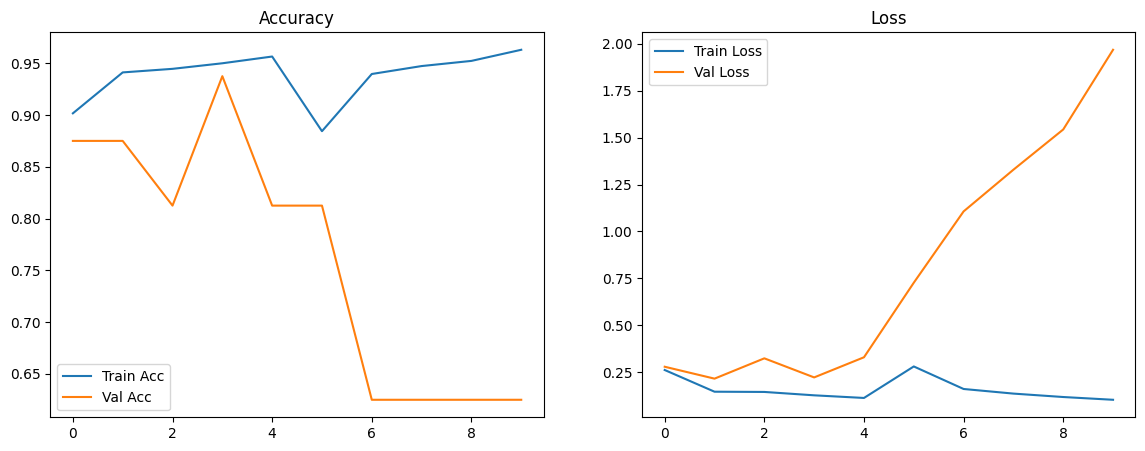

In [22]:
# ====================================
# COMBINE HISTORY FOR PLOTTING
# ====================================
def combine_histories(h1, h2):
    history = {}
    for k in h1.history.keys():
        history[k] = h1.history[k] + h2.history[k]
    return history

full_history = combine_histories(history_head, history_fine)

# ====================================
# PLOT ACCURACY & LOSS
# ====================================
epochs_range = range(len(full_history["accuracy"]))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, full_history["accuracy"], label="Train Acc")
plt.plot(epochs_range, full_history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, full_history["loss"], label="Train Loss")
plt.plot(epochs_range, full_history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.show()



## Evaluate on Test Set

In [23]:
# ====================================
# TEST SET EVALUATION
# ====================================
test_preds = model.predict(test_gen)
y_pred = np.argmax(test_preds, axis=1)
y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# ====================================
# PRECISION / RECALL / F1 TABLE
# ====================================
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.33      0.50       234
   PNEUMONIA       0.71      1.00      0.83       390

    accuracy                           0.75       624
   macro avg       0.86      0.67      0.67       624
weighted avg       0.82      0.75      0.71       624


Confusion Matrix:
 [[ 78 156]
 [  0 390]]


,precision,recall,f1-score,support
NORMAL,1.000000,0.333333,0.500000,234.00
PNEUMONIA,0.714286,1.000000,0.833333,390.00
accuracy,0.750000,0.750000,0.750000,0.75
macro avg,0.857143,0.666667,0.666667,624.00
weighted avg,0.821429,0.750000,0.708333,624.00


In [24]:
from tensorflow.keras.preprocessing import image

def predict_image(model_path, img_path, class_indices):
    model = keras.models.load_model(model_path)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)
    class_id = np.argmax(preds)

    inv_map = {v: k for k, v in class_indices.items()}
    return inv_map[class_id], preds